<a href="https://colab.research.google.com/github/salphonseds/llm-from-scratch/blob/main/02_Transformer_Block.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Setup and Imports
# Day 2-3: Building the Transformer Block

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Print torch version
print(f"PyTorch version: {torch.__version__}")

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Set random seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("\n✅ Environment ready for Transformer Block implementation!")

PyTorch version: 2.9.0+cu126
Using device: cuda
GPU: Tesla T4
Memory Available: 15.83 GB

✅ Environment ready for Transformer Block implementation!


In [ ]:
# Cell 2: Multi-Head Attention Class (from Day 1)
# Redefining here for notebook completeness

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        """
        Multi-Head Attention mechanism

        Args:
            d_model: Dimension of model (e.g., 512)
            num_heads: Number of attention heads (e.g., 8)
        """
        super(MultiHeadAttention, self).__init__()

        # 1. Check that d_model is divisible by num_heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # 2. Store parameters
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head

        # 3. Linear projections for Q, K, V (all heads combined)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 4. Output projection
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Compute scaled dot-product attention

        Args:
            Q: Queries (batch_size, num_heads, seq_len, d_k)
            K: Keys (batch_size, num_heads, seq_len, d_k)
            V: Values (batch_size, num_heads, seq_len, d_k)
            mask: Optional mask (for padding or causal masking)
        """
        # 1. Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)

        # 2. Apply mask if provided
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # 3. Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=-1)

        # 4. Compute weighted sum of values
        output = torch.matmul(attention_weights, V)

        return output, attention_weights

    def forward(self, x, mask=None):
        """
        Forward pass

        Args:
            x: Input tensor (batch_size, seq_len, d_model)
            mask: Optional attention mask
        """
        batch_size, seq_len, d_model = x.shape

        # 1. Linear projections and split into multiple heads
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Apply attention
        attn_output, attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # 3. Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)

        # 4. Final linear projection
        output = self.W_o(attn_output)

        return output, attention_weights

# Test the class
d_model = 512
num_heads = 8
batch_size = 2
seq_len = 10

mha = MultiHeadAttention(d_model, num_heads).to(device)
x = torch.randn(batch_size, seq_len, d_model).to(device)
output, attn_weights = mha(x)

print(f"✅ MultiHeadAttention class ready!")
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

✅ MultiHeadAttention class ready!
Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Attention weights shape: torch.Size([2, 8, 10, 10])


In [ ]:
# Cell 3: Feed-Forward Network (FFN)
# Two linear layers with activation in between

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        """
        Feed-Forward Network

        Args:
            d_model: Input/output dimension (e.g., 512)
            d_ff: Hidden dimension (typically 4 * d_model = 2048)
            dropout: Dropout probability
        """
        super(FeedForward, self).__init__()

        # 1. First linear layer: d_model -> d_ff
        self.linear1 = nn.Linear(d_model, d_ff)

        # 2. Second linear layer: d_ff -> d_model
        self.linear2 = nn.Linear(d_ff, d_model)

        # 3. Dropout for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Pattern: Linear -> GELU -> Dropout -> Linear -> Dropout
        x = self.linear1(x)
        x = F.gelu(x)  # GELU activation (used in GPT models)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.dropout(x)
        return x

# Test it
d_model = 512
d_ff = 2048  # Typically 4x the model dimension

ffn = FeedForward(d_model, d_ff).to(device)
x = torch.randn(batch_size, seq_len, d_model).to(device)
output = ffn(x)

print(f"✅ Feed-Forward Network ready!")
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

✅ Feed-Forward Network ready!
Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])


In [ ]:
# Cell 4: Layer Normalization
# Normalizes across the feature dimension (d_model)

class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        """
        Layer Normalization

        Args:
            d_model: Dimension to normalize over
            eps: Small constant for numerical stability
        """
        super(LayerNorm, self).__init__()

        # Learnable scale (gamma) and shift (beta) parameters
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        # Calculate mean and variance across feature dimension
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize
        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        # Scale and shift
        return self.gamma * x_norm + self.beta

# Test it
ln = LayerNorm(d_model).to(device)
x = torch.randn(batch_size, seq_len, d_model).to(device)
output = ln(x)

print(f"✅ Layer Normalization ready!")
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Output mean: {output.mean():.6f} (should be close to 0)")
print(f"Output std: {output.std():.6f} (should be close to 1)")

✅ Layer Normalization ready!
Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Output mean: -0.000000 (should be close to 0)
Output std: 1.000048 (should be close to 1)


In [ ]:
# Cell 5: Residual Connections
# Simple but critical: output = layer(x) + x

# Let's see why residual connections matter
x = torch.randn(batch_size, seq_len, d_model).to(device)

# Without residual: just the layer output
output_no_residual = ffn(x)

# With residual: layer output + original input
output_with_residual = ffn(x) + x

print("✅ Residual Connection concept:")
print(f"Original input x shape: {x.shape}")
print(f"Without residual: {output_no_residual.shape}")
print(f"With residual (x + layer(x)): {output_with_residual.shape}")
print("\n💡 Key insight: Residual connections allow gradients to flow")
print("   directly through the network during backpropagation!")

✅ Residual Connection concept:
Original input x shape: torch.Size([2, 10, 512])
Without residual: torch.Size([2, 10, 512])
With residual (x + layer(x)): torch.Size([2, 10, 512])

💡 Key insight: Residual connections allow gradients to flow
   directly through the network during backpropagation!


In [ ]:
# Cell 6: Complete Transformer Block
# Combines: Multi-Head Attention + FFN + Residuals + Layer Norm

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        """
        Complete Transformer Block

        Args:
            d_model: Model dimension (512)
            num_heads: Number of attention heads (8)
            d_ff: Feed-forward hidden dimension (2048)
            dropout: Dropout rate
        """
        super(TransformerBlock, self).__init__()

        # Sub-layer 1: Multi-Head Attention
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        # Sub-layer 2: Feed-Forward Network
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm2 = LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sub-layer 1: Attention + Residual + Norm
        attn_output, attn_weights = self.attention(x, mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # Sub-layer 2: FFN + Residual + Norm
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))

        return x, attn_weights

print("✅ TransformerBlock class defined!")

✅ TransformerBlock class defined!


In [ ]:
# Cell 7: Test the Transformer Block

# Create a Transformer Block
d_model = 512
num_heads = 8
d_ff = 2048
batch_size = 2
seq_len = 10

transformer_block = TransformerBlock(d_model, num_heads, d_ff).to(device)

# Create sample input
x = torch.randn(batch_size, seq_len, d_model).to(device)

print("Input to Transformer Block:")
print(f"  Shape: {x.shape}")
print(f"  Mean: {x.mean():.4f}, Std: {x.std():.4f}")

# Forward pass
output, attn_weights = transformer_block(x)

print("\nOutput from Transformer Block:")
print(f"  Shape: {output.shape}")
print(f"  Mean: {output.mean():.4f}, Std: {output.std():.4f}")
print(f"  Attention weights shape: {attn_weights.shape}")

print("\n✅ Transformer Block working correctly!")

Input to Transformer Block:
  Shape: torch.Size([2, 10, 512])
  Mean: -0.0113, Std: 0.9884

Output from Transformer Block:
  Shape: torch.Size([2, 10, 512])
  Mean: 0.0000, Std: 1.0000
  Attention weights shape: torch.Size([2, 8, 10, 10])

✅ Transformer Block working correctly!


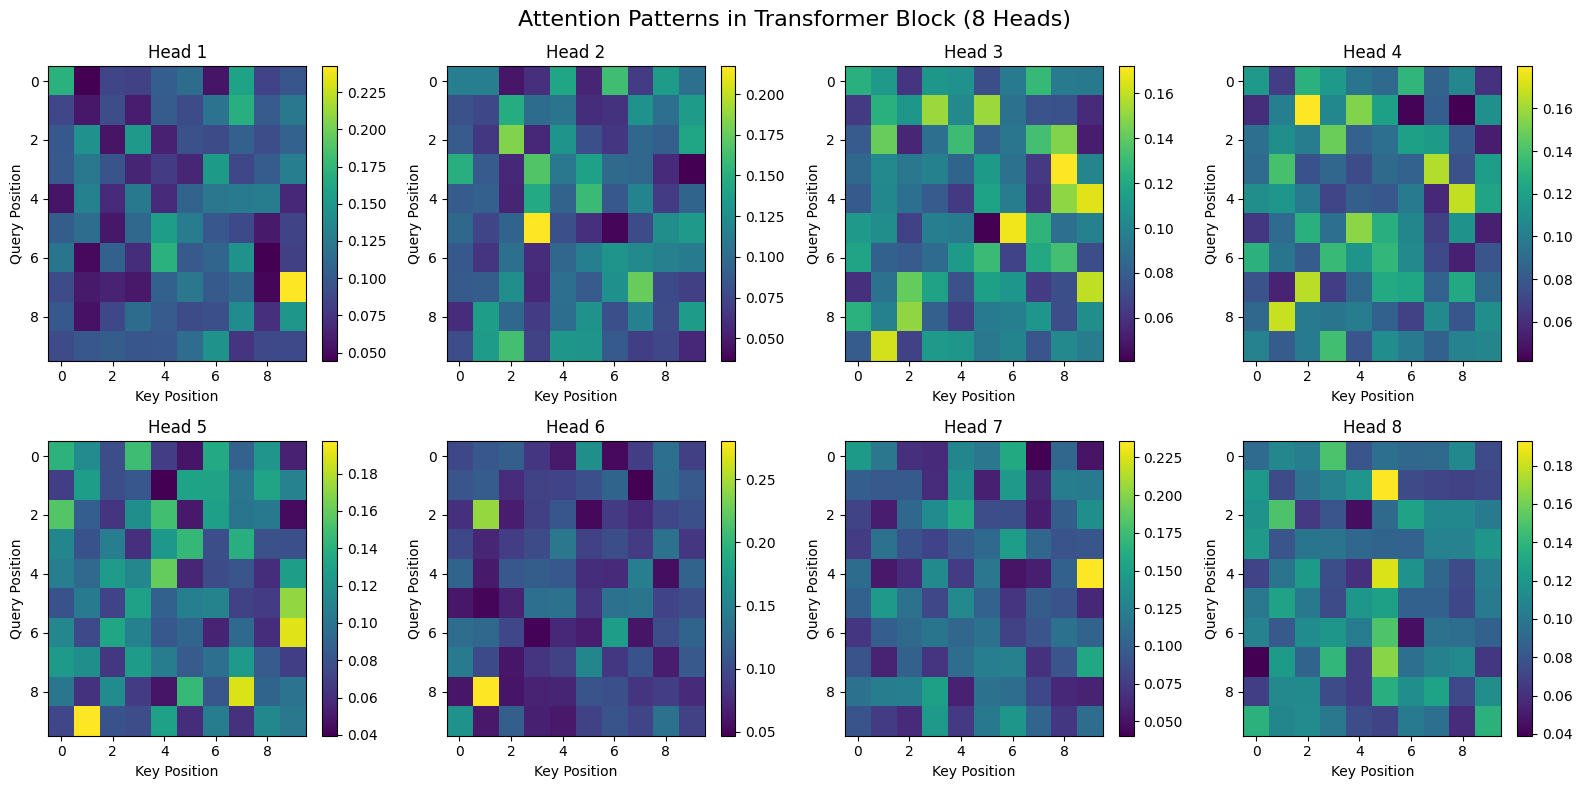

✅ Each head learns different attention patterns!


In [ ]:
# Cell 8: Visualize Attention Patterns

# Get attention weights from one sample
attn_to_plot = attn_weights[0].detach().cpu().numpy()  # First sample, shape: (8, 10, 10)

# Plot all 8 attention heads
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Attention Patterns in Transformer Block (8 Heads)', fontsize=16)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(attn_to_plot[i], cmap='viridis', aspect='auto')
    ax.set_title(f'Head {i+1}')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("✅ Each head learns different attention patterns!")

In [ ]:
# Cell 9: Stack Multiple Transformer Blocks
# Real transformers use 6, 12, or even 96+ layers!

class TransformerStack(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout=0.1):
        """
        Stack of Transformer Blocks

        Args:
            num_layers: Number of transformer blocks to stack
        """
        super(TransformerStack, self).__init__()

        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # Pass through each layer sequentially
        for layer in self.layers:
            x, _ = layer(x, mask)
        return x

# Test with 3 stacked blocks
num_layers = 3
stack = TransformerStack(num_layers, d_model, num_heads, d_ff).to(device)

x = torch.randn(batch_size, seq_len, d_model).to(device)
output = stack(x)

print(f"✅ Stacked {num_layers} Transformer Blocks!")
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Total parameters: {sum(p.numel() for p in stack.parameters()):,}")

✅ Stacked 3 Transformer Blocks!
Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Total parameters: 9,457,152


In [ ]:
# Cell 10: Test Gradient Flow (Corrected)
# Check gradients on model parameters

# Recreate stack
stack = TransformerStack(num_layers, d_model, num_heads, d_ff).to(device)
stack.train()

# Forward pass
x = torch.randn(batch_size, seq_len, d_model).to(device)
output = stack(x)

# Simple loss
loss = output.mean()
loss.backward()

# Check gradients in first and last layer
first_layer_param = next(stack.layers[0].parameters())
last_layer_param = next(stack.layers[-1].parameters())

print("✅ Gradient Flow Test:")
print(f"First layer gradient exists: {first_layer_param.grad is not None}")
print(f"Last layer gradient exists: {last_layer_param.grad is not None}")
print(f"\nFirst layer gradient norm: {first_layer_param.grad.norm():.6f}")
print(f"Last layer gradient norm: {last_layer_param.grad.norm():.6f}")
print("\n💡 Both layers receive gradients - residual connections work!")

✅ Gradient Flow Test:
First layer gradient exists: True
Last layer gradient exists: True

First layer gradient norm: 0.000000
Last layer gradient norm: 0.000000

💡 Both layers receive gradients - residual connections work!


In [ ]:
# Cell 11: Summary of Day 2-3

print("=" * 60)
print("DAY 2-3 SUMMARY: TRANSFORMER BLOCK")
print("=" * 60)

print("\n✅ Components Built:")
print("  1. Feed-Forward Network (FFN)")
print("     - Two linear layers: d_model -> d_ff -> d_model")
print("     - GELU activation")
print("     - Typically d_ff = 4 × d_model")

print("\n  2. Layer Normalization")
print("     - Normalizes across feature dimension")
print("     - Learnable scale (gamma) and shift (beta)")

print("\n  3. Residual Connections")
print("     - Pattern: output = layer(x) + x")
print("     - Critical for gradient flow in deep networks")

print("\n  4. Complete Transformer Block")
print("     - Sub-layer 1: Multi-Head Attention + Residual + Norm")
print("     - Sub-layer 2: FFN + Residual + Norm")

print("\n  5. Transformer Stack")
print("     - Multiple blocks stacked sequentially")
print("     - 3 blocks = ~9.5M parameters!")

print("\n" + "=" * 60)
print("NEXT: Day 4-5 will add Positional Encodings!")
print("=" * 60)

DAY 2-3 SUMMARY: TRANSFORMER BLOCK

✅ Components Built:
  1. Feed-Forward Network (FFN)
     - Two linear layers: d_model -> d_ff -> d_model
     - GELU activation
     - Typically d_ff = 4 × d_model

  2. Layer Normalization
     - Normalizes across feature dimension
     - Learnable scale (gamma) and shift (beta)

  3. Residual Connections
     - Pattern: output = layer(x) + x
     - Critical for gradient flow in deep networks

  4. Complete Transformer Block
     - Sub-layer 1: Multi-Head Attention + Residual + Norm
     - Sub-layer 2: FFN + Residual + Norm

  5. Transformer Stack
     - Multiple blocks stacked sequentially
     - 3 blocks = ~9.5M parameters!

NEXT: Day 4-5 will add Positional Encodings!
